In [1]:
import pandas as pd
import numpy as np
import warnings

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, StackingRegressor
from sklearn.linear_model import Ridge
from xgboost import XGBRegressor

warnings.filterwarnings("ignore")

In [2]:
# -------------------------
# 1. LOAD DATASET
# -------------------------
df = pd.read_csv(r"Crop_Yield_final.csv")
df.head(5)


,Fertilizer,temp,N,P,K,yeild
0,80.0,28,80.0,24.0,20.0,12.0
1,77.0,27,78.0,23.0,20.0,12.0
2,80.0,26,80.0,24.0,20.0,12.0
3,80.0,28,80.0,24.0,20.0,12.0
4,78.0,27,78.0,23.0,19.0,12.0


In [3]:
# -------------------------
# 1. CLEAN COLUMN NAMES
# -------------------------
df.columns = df.columns.str.strip().str.lower()

if 'yeild' in df.columns:
    df.rename(columns={'yeild': 'yield'}, inplace=True)

print("Columns:", df.columns.tolist())
print("Initial Shape:", df.shape)

Columns: ['fertilizer', 'temp', 'n', 'p', 'k', 'yield']
Initial Shape: (5096, 6)


In [4]:
# -------------------------
# 2. CHECK MISSING VALUES
# -------------------------
print("\nMissing Values Before Conversion:")
print(df.isnull().sum())


Missing Values Before Conversion:
fertilizer    58
temp          73
n             80
p             60
k             74
yield         70
dtype: int64


In [5]:
# -------------------------
# 3. CONVERT TO NUMERIC
# -------------------------
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')
print("\nData Types After Numeric Conversion:")
print(df.dtypes)


Data Types After Numeric Conversion:
fertilizer    float64
temp          float64
n             float64
p             float64
k             float64
yield         float64
dtype: object


In [6]:
# -------------------------
# 4. CONVERT NEGATIVE VALUES TO POSITIVE
# -------------------------
for col in df.columns:
    df[col] = df[col].abs()

print("\nCheck Negative Values After abs():")
print((df < 0).sum())


Check Negative Values After abs():
fertilizer    0
temp          0
n             0
p             0
k             0
yield         0
dtype: int64


In [7]:
# -------------------------
# 5. FILL MISSING VALUES
# -------------------------
df.fillna(df.median(numeric_only=True), inplace=True)

print("\nMissing Values After Filling:")
print(df.isnull().sum())


Missing Values After Filling:
fertilizer    0
temp          0
n             0
p             0
k             0
yield         0
dtype: int64


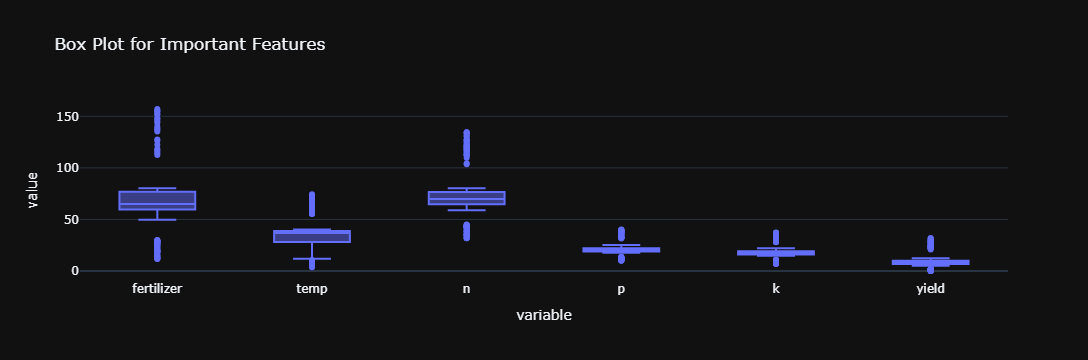

In [8]:
import plotly.express as px

cols = ['fertilizer', 'temp', 'n', 'p', 'k', 'yield']

fig = px.box(
    df,
    y=cols,
    title="Box Plot for Important Features",
    template='plotly_dark'
)

fig.show()

In [10]:
# -------------------------
# 6. REMOVE OUTLIERS USING IQR
# -------------------------
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1

before_rows = df.shape[0]

df = df[~((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))).any(axis=1)]

after_rows = df.shape[0]

print("\nOutlier Removal:")
print("Rows Before:", before_rows)
print("Rows After :", after_rows)
print("Outliers Removed:", before_rows - after_rows)

print("\nFinal Shape After Preprocessing:", df.shape)


Outlier Removal:
Rows Before: 4849
Rows After : 4849
Outliers Removed: 0

Final Shape After Preprocessing: (4849, 6)


In [11]:
# -------------------------
# 6. FEATURE ENGINEERING
# -------------------------
df['npk_sum'] = df['n'] + df['p'] + df['k']
df['npk_mean'] = (df['n'] + df['p'] + df['k']) / 3
df['fert_temp'] = df['fertilizer'] * df['temp']
df['n_p'] = df['n'] * df['p']
df['p_k'] = df['p'] * df['k']
df['n_k'] = df['n'] * df['k']

In [12]:
# -------------------------
# 7. DEFINE FEATURES AND TARGET
# -------------------------
X = df.drop('yield', axis=1)
y = df['yield']

In [13]:
# -------------------------
# 8. POLYNOMIAL FEATURES
# -------------------------
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X)

# -------------------------
# 9. SCALING
# -------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_poly)

In [14]:
# -------------------------
# 10. TRAIN TEST SPLIT
# -------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [15]:
# -------------------------
# 11. BASE MODELS
# -------------------------
estimators = [
    ('rf', RandomForestRegressor(
        n_estimators=100,
        max_depth=12,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42
    )),
 
    ('xgb', XGBRegressor(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective='reg:squarederror',
        random_state=42
    ))
]

In [17]:
# -------------------------
# 12. STACKING ENSEMBLE MODEL
# -------------------------
model = StackingRegressor(
    estimators=estimators,
    final_estimator= RandomForestRegressor()
)

# -------------------------
# 13. TRAIN MODEL
# -------------------------
model.fit(X_train, y_train)

# -------------------------
# 14. PREDICTION
# -------------------------
y_pred = model.predict(X_test)

# -------------------------

In [18]:
# -------------------------
# 15. EVALUATION
# -------------------------
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\nStacking Ensemble Results")
print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)



Stacking Ensemble Results
MAE : 0.20055727148300703
MSE : 0.14065280165045876
RMSE: 0.37503706703532486
R2 Score: 0.9635416199282844


In [ ]:
# -------------------------
# 16. CROSS VALIDATION
# -------------------------
cv_scores = cross_val_score(model, X_scaled, y, cv=5, scoring='r2')
print("\nCross Validation R2 Scores:", cv_scores)
print("Mean CV R2:", cv_scores.mean())

In [ ]:
# Train score
train_pred = model.predict(X_train)
r2_train = r2_score(y_train, train_pred)

# Test score
test_pred = model.predict(X_test)
r2_test = r2_score(y_test, test_pred)

print("Train R2:", r2_train)
print("Test R2 :", r2_test)
print("Difference:", r2_train - r2_test)

In [19]:
# -------------------------
# CALCULATE METRICS FOR EACH MODEL
# -------------------------

# Random Forest
y_pred_rf = estimators[0][1].fit(X_train, y_train).predict(X_test)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

# XGBoost
y_pred_xgb = estimators[1][1].fit(X_train, y_train).predict(X_test)
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)

# Stacking
mae_stack = mae
rmse_stack = rmse
r2_stack = r2

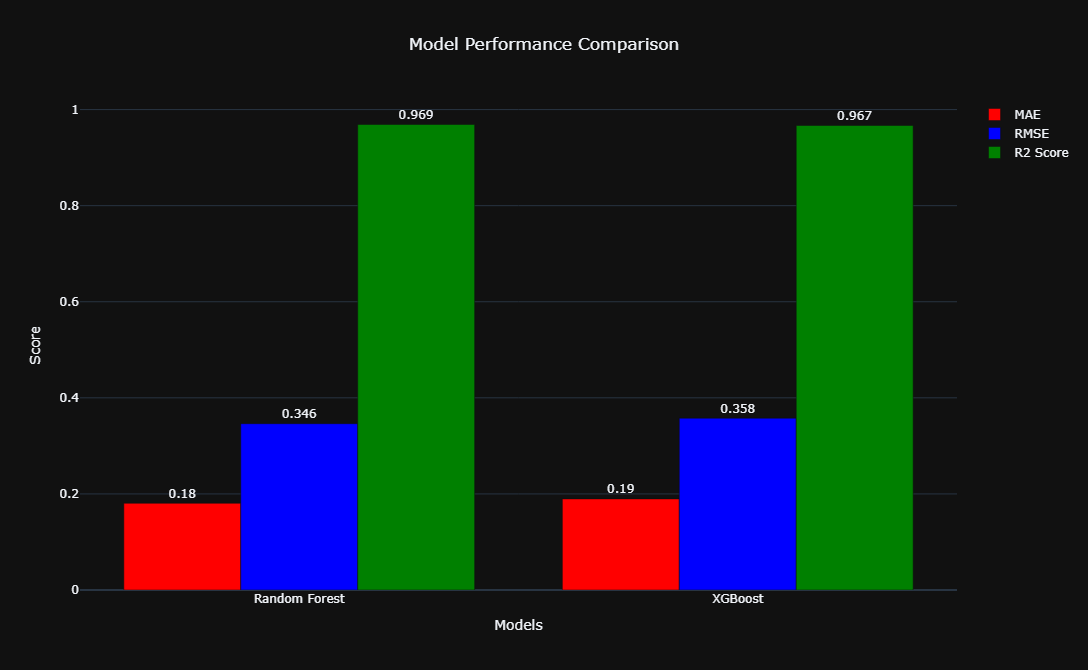

In [20]:
# -------------------------
# 18. MODEL COMPARISON GRAPH
# -------------------------
# -------------------------
# 18. MODEL COMPARISON GRAPH
# -------------------------
import plotly.graph_objects as go

models = ['Random Forest', 'XGBoost']

mae_values = [mae_rf, mae_xgb]
rmse_values = [rmse_rf, rmse_xgb]
r2_values = [r2_rf, r2_xgb]

fig = go.Figure()

# MAE
fig.add_trace(go.Bar(
    x=models,
    y=mae_values,
    name='MAE',
    marker_color='red',
    text=[round(i, 3) for i in mae_values],
    textposition='outside',
    hovertemplate='Model: %{x}<br>MAE: %{y:.3f}<extra></extra>'
))

# RMSE
fig.add_trace(go.Bar(
    x=models,
    y=rmse_values,
    name='RMSE',
    marker_color='blue',
    text=[round(i, 3) for i in rmse_values],
    textposition='outside',
    hovertemplate='Model: %{x}<br>RMSE: %{y:.3f}<extra></extra>'
))

# R2
fig.add_trace(go.Bar(
    x=models,
    y=r2_values,
    name='R2 Score',
    marker_color='green',
    text=[round(i, 3) for i in r2_values],
    textposition='outside',
    hovertemplate='Model: %{x}<br>R2 Score: %{y:.3f}<extra></extra>'
))

fig.update_layout(
    title='Model Performance Comparison',
    xaxis_title='Models',
    yaxis_title='Score',
    barmode='group',
    template='plotly_dark',
    title_x=0.5,
    height=650,
    width=1100
)

fig.show()

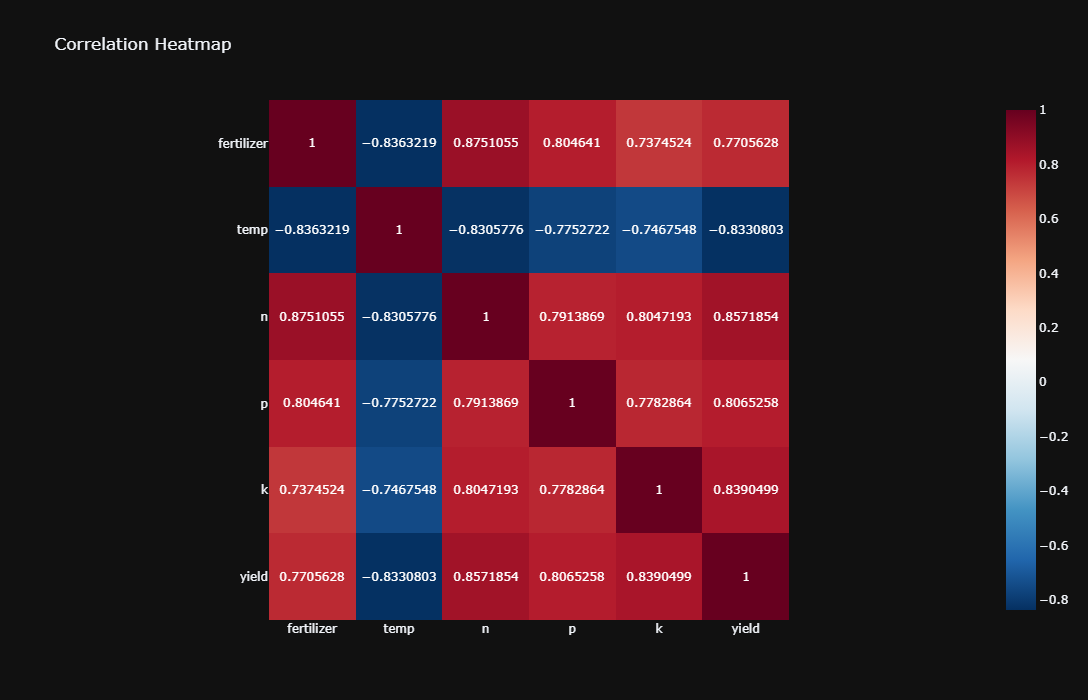

In [21]:
import plotly.express as px

cols = ['fertilizer', 'temp', 'n', 'p', 'k', 'yield']
corr = df[cols].corr()

fig = px.imshow(
    corr,
    text_auto=True,
    color_continuous_scale='RdBu_r',
    title="Correlation Heatmap"
)

fig.update_layout(
    width=900,     # increase width
    height=700,    # increase height
    template='plotly_dark'
)

fig.show()

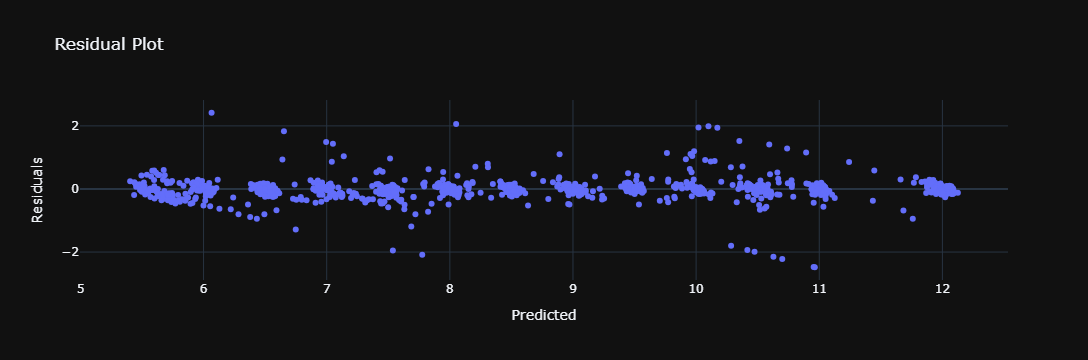

In [22]:
residuals = y_test - y_pred

fig = px.scatter(x=y_pred, y=residuals,
                 title="Residual Plot",
                 labels={"x":"Predicted", "y":"Residuals"},
                 template="plotly_dark")

fig.show()


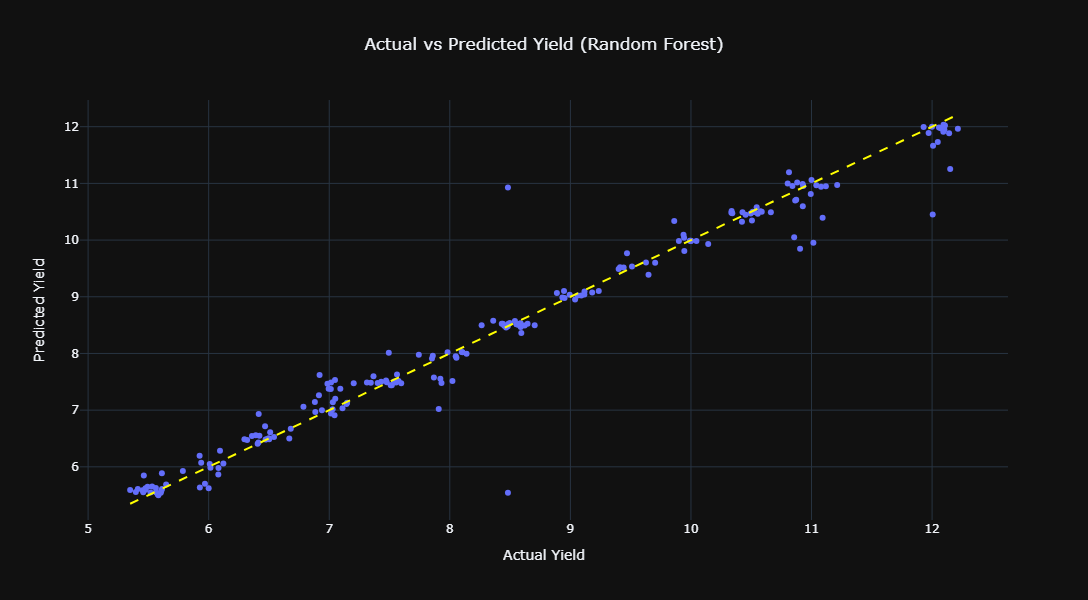

In [23]:
import plotly.express as px
import pandas as pd
import numpy as np

# SAMPLE DATA
sample_size = 200
indices = np.random.choice(len(y_test), sample_size, replace=False)

actual_sample = y_test.iloc[indices]
pred_sample = y_pred_rf[indices]

sample_df = pd.DataFrame({
    "Actual Yield": actual_sample,
    "Predicted Yield": pred_sample
})

# SCATTER PLOT
fig = px.scatter(
    sample_df,
    x="Actual Yield",
    y="Predicted Yield",
    title="Actual vs Predicted Yield (Random Forest)",
    template="plotly_dark",
    hover_data=["Actual Yield", "Predicted Yield"]
)

# Perfect prediction line
fig.add_shape(
    type="line",
    x0=sample_df["Actual Yield"].min(),
    y0=sample_df["Actual Yield"].min(),
    x1=sample_df["Actual Yield"].max(),
    y1=sample_df["Actual Yield"].max(),
    line=dict(color="yellow", dash="dash")
)

fig.update_layout(
    title_x=0.5,
    height=600,
    width=900
)

fig.show()

In [24]:
import plotly.express as px
import pandas as pd
from sklearn.ensemble import RandomForestRegressor

# -------------------------
# ORIGINAL FEATURES ONLY
# -------------------------
X_orig = df[['fertilizer', 'temp', 'n', 'p', 'k']]
y_orig = df['yield']

# Train Random Forest
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_orig, y_orig)

# Feature Importance
importance = rf_model.feature_importances_

feat_df = pd.DataFrame({
    "Feature": ['fertilizer', 'temp', 'n', 'p', 'k'],
    "Importance": importance
})

# Sort values
feat_df = feat_df.sort_values(by="Importance", ascending=True)

# Plot graph
fig = px.bar(
    feat_df,
    x="Importance",
    y="Feature",
    orientation='h',
    title="Feature Importance (Original Dataset Features)",
    template="plotly_dark",
    hover_data=["Importance"],
    text="Importance"
)

fig.update_layout(
    title_x=0.5,
    height=500,
    width=800
)

fig.show()